In [1]:
import os
os.environ["PATH"] = "/data/apps/extern/spack_on/gcc/9.3.0/texlive/20220321-oikenzl6gekq5lsohdm6jnnuj276s2ba/bin/x86_64-linux:" + os.environ.get("PATH", "")

import sys
from pathlib import Path

this_notebook = Path().resolve()

project_root = this_notebook.parents[0]

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

## Module imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LogNorm, SymLogNorm
import matplotlib as mpl
from cycler import cycler

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

N = 3
cmap = mpl.colormaps["viridis"].resampled(N)
colors = [cmap(i) for i in range(N)]
mpl.rcParams["axes.prop_cycle"] = cycler(color=colors)
# mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=mpl.colormaps['Set2'].colors)

#import Zeus
import zeus21

#set up the CLASS cosmology
from classy import Class
import mcfit
from scipy.interpolate import interp1d
from tqdm import tqdm
# from scipy.integrate import simps as simpson
from scipy.integrate import simpson
from scipy.special import i0

import zeus21

## Zeus setup

In [80]:
ombh2 = 0.02242 
omch2 = 0.11933
tau_re = 0.0544
hLittle = 0.6766
ns = 0.9665
As = np.exp(3.047)*10**(-10.)

UserParams = zeus21.User_Parameters(precisionboost=1.2)
# CosmoParams_input = zeus21.Cosmo_Parameters_Input(
#     omegac = omch2, omegab = ombh2, h_fid = hLittle, As = As, ns = ns, tau_fid = tau_re, 
#     USE_RELATIVE_VELOCITIES = True, Flag_emulate_21cmfast=False)

# Tutorial-matched cosmology for comparison
omega_cdm = 0.12
CosmoParams_input = zeus21.Cosmo_Parameters_Input(
    omegac = omega_cdm,
    USE_RELATIVE_VELOCITIES = True,
    Flag_emulate_21cmfast=False)

## 21-cm power spectrum: v1 vs v2

In [81]:
from scipy.interpolate import interp1d

cosmo_v1 = zeus21.cosmology
corr_v1 = zeus21.correlations
cosmo_v2 = zeus21.cosmology_v2
corr_v2 = zeus21.correlations_v2

ClassyCosmo_v1 = cosmo_v1.runclass(CosmoParams_input)
CosmoParams_v1 = zeus21.Cosmo_Parameters(UserParams, CosmoParams_input, ClassyCosmo_v1)
CorrFClass_v1 = corr_v1.Correlations(UserParams, CosmoParams_v1, ClassyCosmo_v1)
HMFintclass_v1 = cosmo_v1.HMF_interpolator(UserParams, CosmoParams_v1, ClassyCosmo_v1)

ClassyCosmo_v2 = cosmo_v2.runclass(CosmoParams_input)
CosmoParams_v2 = zeus21.Cosmo_Parameters(UserParams, CosmoParams_input, ClassyCosmo_v2)
CorrFClass_v2 = corr_v2.Correlations(UserParams, CosmoParams_v2, ClassyCosmo_v2)
HMFintclass_v2 = cosmo_v2.HMF_interpolator(UserParams, CosmoParams_v2, ClassyCosmo_v2)

In [82]:
### POP II quantities first

################################
### Model Parameters
astromodel = 0            # ASTRO MODEL: 0 for GALUMI-like, 1 for 21cmfast-like, default 0
accretion_model = 0       # ACCRETION MODEL: 0 for exponential, 1 for EPS, default EXP

################################
### SFR(Mh) Parameteres
alphastar = 0.5          # alphastar powerlaw index for low masses, default 0.5
betastar = -0.5           # betastar powerlaw index for high masses, default -0.5
# epsstar = 10**-1.             # epsilonstar = fstar at Mc
Mc = 3e11                 # Pivot mass at which the power law cuts for model 0, default Mc = 3e11
dlog10epsstardz = 0.0     # dlog10epsilonstar/dz, default 0

################################
### Escape fraction parameters
fesc10 = 0.1              # fesc(M) parameter. Power law normalized (fesc10) at M=1e10 Msun with index alphaesc
alphaesc = 0.0
# L40_xray = 10**0.5        # L40_xray: soft-band (E<2 keV) lum/SFR in Xrays in units of 10^40 erg/s/(Msun/yr)
E0_xray = 500.            # E0_xray: minimum energy in eV
alpha_xray = -1.0         # Xray SED power-law index
Emax_xray_norm=2000       # max energy in eV to normalize SED. Keep at 2000 eV normally

################################
### LyA parameters
Nalpha_lyA_II = 9690      # number of Pop II photons between LyA and Ly Cont. per baryon (from BL05)
Nalpha_lyA_III = 17900    # number of Pop III photons between LyA and Ly Cont. per baryon value of 17900 is from Klessen & Glover 2023 (2303.12500), table A2

################################
### MTURN Parameters: 
Mturn_fixed = None        # Mturn_fixed: None if use Matom(z) at each z, Some value if fixed Mturn
FLAG_MTURN_SHARP= False   # Mturn_sharp: False if regular exponential cutoff, True if sharp cutoff, active only if Mturn_fixed is on

################################
### UVLF Parameters
C0dust = 4.43             # DUST PARAMETERS FOR UVLFs
C1dust = 1.99
sigmaUV = 0.5             # stochasticity (gaussian rms) in the halo-galaxy connection P(MUV | Mh) - TODO: only used in UVLF not sfrd

################################
ZMIN = 10.0               # down to which z we compute the evolution



################################
# Pop III Quantities
alphastar_III = 0 
betastar_III = 0
fstar_III = 10**(-3.0)
Mc_III = 1e7
dlog10epsstardz_III = 0.0

fesc7_III = 10**(-1.35)
alphaesc_III = -0.3
L40_xray_III = 10**0.5
alpha_xray_III = -1.0


# USE_POPIII = True
# USE_LW_FEEDBACK = True

A_LW = 2.0
beta_LW = 0.6

A_vcb = 1.0
beta_vcb = 1.8

# Tutorial-matched astro parameters
epsilon_star = 0.15
L40_xray_tut = 3.0
USE_POPIII_TUT = True
# USE_LW_FEEDBACK_TUT = False

#set up your astro parameters too, here the peak of f*(Mh) as an example

# AstroParams = zeus21.Astro_Parameters(UserParams,
#                                       CosmoParams_v1, 
#                                       # astromodel = astromodel, 
#                                       # accretion_model = accretion_model,
#                                       
#                                       # alphastar = alphastar, 
#                                       # betastar = betastar, 
#                                       epsstar = epsstar, 
#                                       # Mc = Mc, 
#                                       # dlog10epsstardz = dlog10epsstardz,
#                                       
#                                       # fesc10 = fesc10, 
#                                       # alphaesc = alphaesc,
#                                       L40_xray = L40_xray, 
#                                       # E0_xray = E0_xray, 
#                                       # alpha_xray = alpha_xray, 
#                                       # Emax_xray_norm = Emax_xray_norm, 
#                                       
#                                       # Nalpha_lyA_II = Nalpha_lyA_II, 
#                                       # Nalpha_lyA_III = Nalpha_lyA_III,
#                                       
#                                       # Mturn_fixed = Mturn_fixed, 
#                                       # FLAG_MTURN_SHARP = FLAG_MTURN_SHARP,
#                                       
#                                       # C0dust = C0dust, 
#                                       # C1dust = C1dust,
#                                       # sigmaUV = sigmaUV,
#                                     
#                                     
#                                       USE_POPIII = USE_POPIII, 
#                                       # USE_LW_FEEDBACK = USE_LW_FEEDBACK,
#                                       
#                                       # alphastar_III = alphastar_III, 
#                                       # betastar_III = betastar_III,
#                                       # fstar_III = fstar_III,
#                                       # Mc_III = Mc_III,
#                                       # dlog10epsstardz_III = dlog10epsstardz_III,
#                                       
#                                       # fesc7_III = fesc7_III,
#                                       # alphaesc_III = alphaesc_III,
#                                       # L40_xray_III = L40_xray_III,
#                                       # alpha_xray_III = alpha_xray_III,
                                               
#                                       # A_LW = A_LW,
#                                       # beta_LW = beta_LW,
#                                       
#                                       # A_vcb = A_vcb,
#                                       # beta_vcb = beta_vcb
#                                               )

AstroParams = zeus21.Astro_Parameters(
    UserParams,
    CosmoParams_v1,
    epsstar=epsilon_star,
    L40_xray=L40_xray_tut,
    USE_POPIII=USE_POPIII_TUT,
    # USE_LW_FEEDBACK=USE_LW_FEEDBACK_TUT,
    )

# AstroParams_v2 = zeus21.Astro_Parameters(UserParams,
#                                       CosmoParams_v2, 
#                                       astromodel = astromodel, 
#                                       accretion_model = accretion_model,
                                      
#                                       alphastar = alphastar, 
#                                       betastar = betastar, 
#                                       epsstar = epsstar, 
#                                       Mc = Mc, 
#                                       dlog10epsstardz = dlog10epsstardz,
                                      
#                                       fesc10 = fesc10, 
#                                       alphaesc = alphaesc,
#                                       L40_xray = L40_xray, 
#                                       E0_xray = E0_xray, 
#                                       alpha_xray = alpha_xray, 
#                                       Emax_xray_norm = Emax_xray_norm, 
                                      
#                                       Nalpha_lyA_II = Nalpha_lyA_II, 
#                                       Nalpha_lyA_III = Nalpha_lyA_III,
                                      
#                                       Mturn_fixed = Mturn_fixed, 
#                                       FLAG_MTURN_SHARP = FLAG_MTURN_SHARP,

#                                       C0dust = C0dust, 
#                                       C1dust = C1dust,
#                                       sigmaUV = sigmaUV,
                                     
                                     
#                                       USE_POPIII = USE_POPIII, 
#                                       USE_LW_FEEDBACK = USE_LW_FEEDBACK,

#                                       alphastar_III = alphastar_III, 
#                                       betastar_III = betastar_III,
#                                       fstar_III = fstar_III,
#                                       Mc_III = Mc_III,
#                                       dlog10epsstardz_III = dlog10epsstardz_III,

#                                       fesc7_III = fesc7_III,
#                                       alphaesc_III = alphaesc_III,
#                                       L40_xray_III = L40_xray_III,
#                                       alpha_xray_III = alpha_xray_III,
                                               
#                                       A_LW = A_LW,
#                                       beta_LW = beta_LW,
                                      
#                                       A_vcb = A_vcb,
#                                       beta_vcb = beta_vcb
#                                                )

In [83]:
CoeffStructure_v1 = zeus21.get_T21_coefficients(
    UserParams, CosmoParams_v1, ClassyCosmo_v1, AstroParams, HMFintclass_v1, zmin=ZMIN
    )
PS_v1 = corr_v1.Power_Spectra(
    UserParams, CosmoParams_v1, AstroParams, ClassyCosmo_v1, CorrFClass_v1, CoeffStructure_v1
    )

CoeffStructure_v2 = zeus21.get_T21_coefficients(
    UserParams, CosmoParams_v2, ClassyCosmo_v2, AstroParams, HMFintclass_v2, zmin=ZMIN
    )
PS_v2 = corr_v2.Power_Spectra(
    UserParams, CosmoParams_v2, AstroParams, ClassyCosmo_v2, CorrFClass_v2, CoeffStructure_v2
    )

In [92]:
z_v1 = np.asarray(CoeffStructure_v1.zintegral)
z_v2 = np.asarray(CoeffStructure_v2.zintegral)
z_min = max(z_v1.min(), z_v2.min())
z_max = min(z_v1.max(), z_v2.max())
z_common = z_v1[(z_v1 >= z_min) & (z_v1 <= z_max)]
if z_common.size == 0:
    raise ValueError("No overlapping z range between v1 and v2 grids")

targets = np.array([12.0, 15.0, 17.0, 18.7, 21.0])
idx = [int(np.argmin(np.abs(z_common - z))) for z in targets]
z_samples = [0] + idx
z_samples_z = z_common[z_samples]

interp_v1 = interp1d(CoeffStructure_v1.zintegral, PS_v1.Deltasq_T21, axis=0, bounds_error=False, fill_value="extrapolate")
interp_v2 = interp1d(CoeffStructure_v2.zintegral, PS_v2.Deltasq_T21, axis=0, bounds_error=False, fill_value="extrapolate")

P21_v1 = interp_v1(z_samples_z)
P21_v2 = interp_v2(z_samples_z)

k_v1 = PS_v1.klist_PS
k_v2 = PS_v2.klist_PS

if not np.allclose(k_v1, k_v2):
    interp_k_v1 = interp1d(k_v1, P21_v1, axis=1, bounds_error=False, fill_value="extrapolate")
    P21_v1 = interp_k_v1(k_v2)

k_plot = k_v2
frac_diff = (P21_v1 - P21_v2) / P21_v1

In [93]:
# Find max |fractional difference| over k and the original z grid
z_v1 = np.asarray(CoeffStructure_v1.zintegral)
z_v2 = np.asarray(CoeffStructure_v2.zintegral)
z_min = max(z_v1.min(), z_v2.min())
z_max = min(z_v1.max(), z_v2.max())
z_common = z_v1[(z_v1 >= z_min) & (z_v1 <= z_max)]
if z_common.size == 0:
    raise ValueError("No overlapping z range between v1 and v2 grids")

P21_v1_full = interp_v1(z_common)
P21_v2_full = interp_v2(z_common)

fd_full = (P21_v1_full - P21_v2_full) / P21_v1_full
abs_fd = np.abs(fd_full)

k_mask_full = (k_plot >= 1e-2) & (k_plot <= 1.0)
abs_fd[:, ~k_mask_full] = np.nan

if not np.any(np.isfinite(abs_fd)):
    raise ValueError("No finite fractional differences found")
flat_idx = np.nanargmax(abs_fd)
z_idx, k_idx = np.unravel_index(flat_idx, abs_fd.shape)
z_at_max = z_common[z_idx]
fd_max = fd_full[z_idx, k_idx]
k_at_max = k_plot[k_idx]
p1_at_max = P21_v1_full[z_idx, k_idx]
p2_at_max = P21_v2_full[z_idx, k_idx]

print(f"max |frac_diff| = {abs(fd_max):.6g} at z = {z_at_max:.6g}, k = {k_at_max:.6g}; signed = {fd_max:.6g}")
print(f"P21_v1 = {p1_at_max:.6g}; P21_v2 = {p2_at_max:.6g}")

max |frac_diff| = 0.652573 at z = 18.7083, k = 0.0343446; signed = -0.652573
P21_v1 = 1.8971; P21_v2 = 3.13509


In [94]:
# Nearest z_common indices for selected redshifts
for z, i in zip(targets, idx):
    print(f"z={z:>5.1f} -> idx={i}, z_common={z_common[i]:.6g}")
print(f"z_samples indices: {z_samples}")
print(f"z_samples values: {z_samples_z}")

z= 12.0 -> idx=11, z_common=11.988
z= 15.0 -> idx=25, z_common=15.0997
z= 17.0 -> idx=32, z_common=16.9465
z= 18.7 -> idx=38, z_common=18.7083
z= 21.0 -> idx=45, z_common=20.9964
z_samples indices: [0, 11, 25, 32, 38, 45]
z_samples values: [10.         11.9879988  15.09974981 16.9465494  18.70828693 20.99643455]


### Plot: power spectra and fractional difference

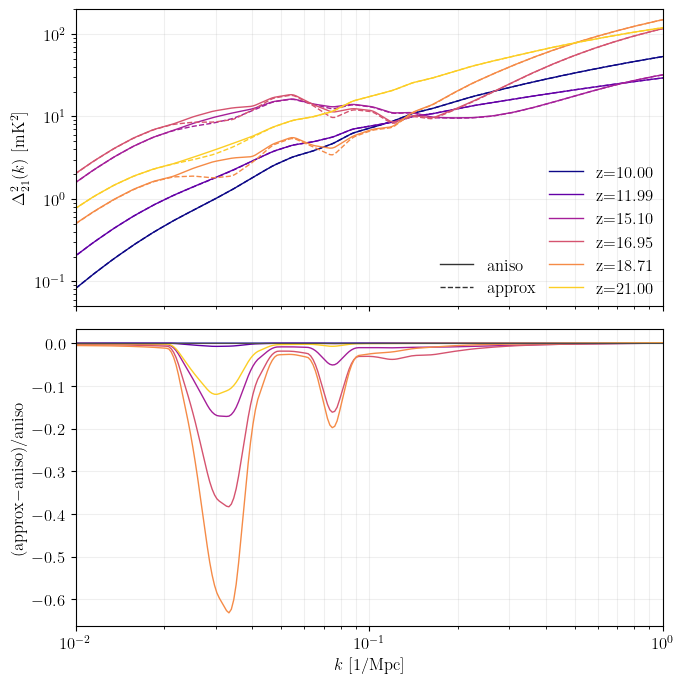

In [98]:
from matplotlib.lines import Line2D

# colors = mpl.colormaps["plasma"].resampled(len(z_samples))
colors = mpl.colormaps["plasma"](np.linspace(0.0, 0.9, len(z_samples)))

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(7, 7), gridspec_kw={"height_ratios": [1, 1]}
    )

def smooth_1d(values, window=7):
    window = max(3, int(window))
    if window % 2 == 0:
        window += 1
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="same")

k_mask = (k_plot > 5e-3) & (k_plot < 2.0)
k_trim = k_plot[k_mask]
logk = np.log10(k_trim)
logk_dense = np.linspace(logk.min(), logk.max(), 300)
k_dense = 10**logk_dense

for i, z in enumerate(z_samples_z):
    color = colors[i]
    p1 = P21_v1[i][k_mask]
    p2 = P21_v2[i][k_mask]
    fd = frac_diff[i][k_mask]

    valid1 = p1 > 0
    valid2 = p2 > 0
    interp_logp1 = interp1d(logk[valid1], np.log10(p1[valid1]), bounds_error=False, fill_value="extrapolate")
    interp_logp2 = interp1d(logk[valid2], np.log10(p2[valid2]), bounds_error=False, fill_value="extrapolate")
    interp_fd = interp1d(logk, fd, bounds_error=False, fill_value="extrapolate")

    logp1_dense = interp_logp1(logk_dense)
    logp2_dense = interp_logp2(logk_dense)
    fd_dense = interp_fd(logk_dense)

    p1_smooth = 10**smooth_1d(logp1_dense, window=1)
    p2_smooth = 10**smooth_1d(logp2_dense, window=1)
    fd_smooth = smooth_1d(fd_dense, window=5)

    ax_top.loglog(k_dense, p1_smooth, ls="--", lw=1, color=color)
    ax_top.loglog(k_dense, p2_smooth, ls="-", lw=1, color=color)
    ax_bot.semilogx(k_dense, fd_smooth, lw=1, color=color)

ax_top.set_ylim(5e-2, 2e2)
ax_top.set_xlim(1e-2, 1)
ax_top.set_ylabel(r"$\Delta^2_{21}(k)$ [mK$^2$]")
ax_bot.set_xlabel(r"$k$ [1/Mpc]")
ax_bot.set_ylabel(r"(approx$-$aniso)/aniso")
ax_bot.axhline(0.0, color="0.3", lw=0.8)

ax_top.grid(True, which="both", axis="x", alpha=0.2)
ax_top.grid(True, which="major", axis="y", alpha=0.2)
ax_bot.grid(True, which="both", alpha=0.2)

z_handles = [Line2D([0], [0], color=colors[i], lw=1, ls="-") for i in range(len(z_samples))]
z_labels = [f"z={z:.2f}" for z in z_samples_z]
style_handles = [
    Line2D([0], [0], color="0.2", lw=1, ls="-"),
    Line2D([0], [0], color="0.2", lw=1, ls="--"),
]
style_labels = ["aniso", "approx"]

legend_z = ax_top.legend(
    z_handles, z_labels, fontsize=12, frameon=False, loc="lower right",
    bbox_to_anchor=(1.0, 0.0), borderaxespad=0.2, handlelength=2.0
    )
ax_top.add_artist(legend_z)
ax_top.legend(
    style_handles, style_labels, fontsize=12, frameon=False, loc="lower right",
    bbox_to_anchor=(0.8, 0.0), borderaxespad=0.2, handlelength=2.0
    )

plt.tight_layout()

## Parameter differences (original)
These are the parameters that originally differed between 21_diff and the tutorial Scenario B setup.

| Parameter | 21_diff original | Tutorial Scenario B | Meaning / scenario |
| --- | --- | --- | --- |
| precisionboost | 1.5 | 1.2 | Sampling density |
| omegab | 0.02242 | default 0.0223828 | Baryon density |
| h_fid | 0.6766 | default 0.67810 | Hubble parameter |
| As | exp(3.047)*1e-10 (~2.10e-9) | default 2.100549e-09 | Primordial amplitude |
| ns | 0.9665 | default 0.9660499 | Scalar spectral tilt |
| tau_fid | 0.0544 | default 0.05430842 | Reionization optical depth |
| epsstar | 0.1 | 0.15 | Pop II star formation efficiency |
| L40_xray | 10**0.5 (~3.16) | 3.0 | Pop II X-ray luminosity per SFR |
| fstar_III | 1e-3 | default 10**(-2.5) (~3.16e-3) | Pop III star formation efficiency |
| L40_xray_III | 10**0.5 (~3.16) | default 3.0 | Pop III X-ray luminosity per SFR |

Other astro/cosmo parameters were either identical to the tutorial or left at the tutorial defaults; some were explicitly set in 21_diff but to the same values (e.g., LW and vcb feedback coefficients).